# Measurement
1. Spectroscopy - goal: resonant freq 
2. separate 0/1, goal: dispersive shift
3. qubit spectroscopy - find qubit mode, power rabi & time rabi (calibrate pi gate) 
4. T1 & Ramsey (T2*) & spin echo(T2) & CPMG (T2)
automation ends
(input of automation: gates, hence need power & time)
5. find the precise qubit freq & pi gate
----- qubit cali ends-----

6. S/ T gates etc or two qubit gate


### Initialization

In [70]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
import os
import laboneq
print(laboneq.__version__)

2.51.0


In [10]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.22 13:10:44.313] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.22 13:10:44.316] INFO    VERSION: laboneq 2.51.0
[2025.08.22 13:10:44.317] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.22 13:10:44.323] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.22 13:10:44.329] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.22 13:10:44.333] INFO    Configuring the device setup
[2025.08.22 13:10:44.342] INFO    The device setup is configured


## Resonator Spectroscopy

In [58]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
start_freq = 100e6 # actual_start_freq = central_freq - start_freq
stop_freq = 300.0e6
center_freq = 7e9
num_points = 1001 # stop - start / (num_points-1)
integration_time = 1e-5
num_averages = 6 # average number = 2^n, n_max = 17

measure_range = -30 # actual power = range (dBm) - 20log(amp)
measure_amp = 0.5
acquire_range = -25
acquire_amp = 0.8 #
# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )

In [59]:
# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter
def res_spectroscopy_cw(freq_sweep, exp_settings):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, exp_settings["num_averages"]),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp_spec.sweep(uid="res_freq", parameter=freq_sweep):
            # readout pulse and data acquisition
            with exp_spec.section(uid="spectroscopy"):
                # resonator signal readout
                exp_spec.acquire(
                    signal="acquire",
                    handle="res_spec",
                    length=exp_settings["integration_time"],
                )
            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec.section(uid="relax", length=1e-6):
                exp_spec.reserve(signal="measure")
                exp_spec.reserve(signal="acquire")

    return exp_spec

In [60]:
# function that returns the calibration of the readout line oscillator for the experimental signals


def res_spec_calib(freq_sweep):

    exp_calibration = Calibration()
    exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = freq_sweep, modulation_type=ModulationType.HARDWARE),
    local_oscillator = Oscillator(uid="qa_lo", frequency = center_freq), range = measure_range, amplitude= measure_amp)
    
    exp_calibration["acquire"] = SignalCalibration(range = acquire_range, amplitude= acquire_amp)

    return exp_calibration


# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# define the experiment with the frequency sweep relevant for qubit 0
freq_sweep = create_readout_freq_sweep("q0", start_freq, stop_freq, num_points)
exp_settings = {"integration_time": integration_time, "num_averages": num_averages}
exp_spec = res_spectroscopy_cw(freq_sweep, exp_settings)

# set signal calibration and signal map for experiment to qubit 0
exp_spec.set_calibration(res_spec_calib(freq_sweep))
exp_spec.set_signal_map(res_spec_map("q0"))

In [61]:
# compile the experiment on the open instrument session
compiled_res_spec = session.compile(exp_spec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet", compiled_res_spec)

[2025.08.22 13:25:49.810] INFO    Starting LabOne Q Compiler run...


[2025.08.22 13:25:49.995] INFO    Schedule completed. [0.183 s]
[2025.08.22 13:25:50.489] INFO    Code generation completed for all AWGs. [0.496 s]
[2025.08.22 13:25:50.489] INFO    Completed compilation step 1 of 1. [0.681 s]
[2025.08.22 13:25:50.489] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:50.489] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.22 13:25:50.489] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:50.500] INFO      device_shfqc     0         21            0           0         0  
[2025.08.22 13:25:50.501] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:50.502] INFO      TOTAL                      21            0                     0  
[2025.08.22 13:25:50.502] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:50.505] INFO    Finished LabOne Q 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Resonator_Spectroscopy_Pulse_Sheet_2025-08-22-13-25-50.html

In [62]:
# run the compiled experiemnt and extracted the data
result = session.run(compiled_res_spec)
amp = result.acquired_results["res_spec"].data
freqs = result.acquired_results["res_spec"].axis[0]

[2025.08.22 13:25:51.153] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.22 13:25:51.155] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.22 13:25:51.155] INFO    Configuring the device setup
[2025.08.22 13:25:51.168] INFO    The device setup is configured
[2025.08.22 13:25:51.487] INFO    Starting near-time execution...
[2025.08.22 13:25:52.291] INFO    Finished near-time execution.


C:\Users\qubit\AppData\Local\Temp\ipykernel_23052\1210314474.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="best")


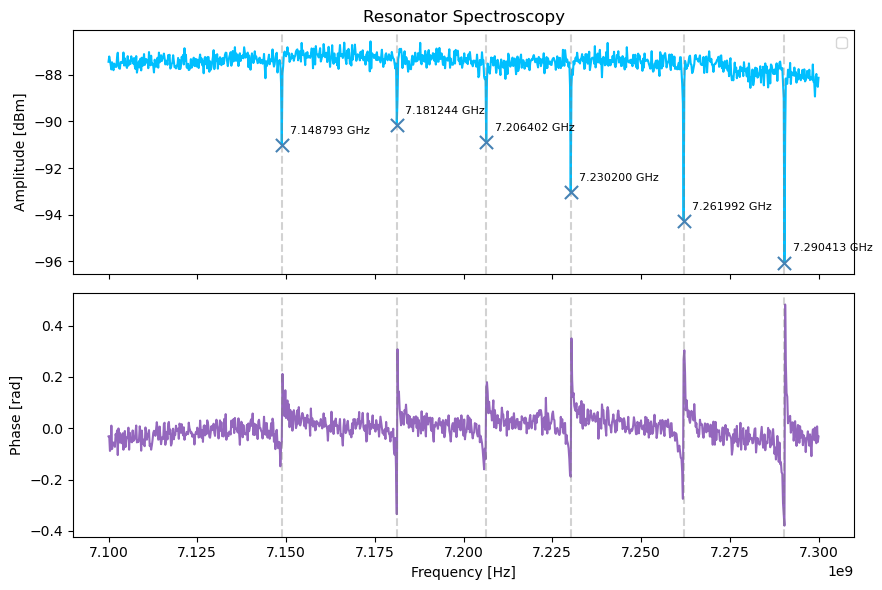

Residual slope (rad/GHz) after detrend: -1.772e-12
Saved outputs in: resonator_results
Dips (GHz): [7.14879262 7.1812436  7.20640225 7.23020023 7.26199166 7.2904129 ]


In [84]:
# --------- COMPUTE BASIC QUANTITIES ---------
freq_list = np.asarray(freqs, dtype=float).ravel() + float(center_freq)
amp = np.asarray(amp).ravel()

amplitude = np.abs(amp)
power_W = (amplitude**2) / 50.0
amp_dbm = 10.0 * np.log10(power_W / 1e-3)

# --------- SORT BY FREQUENCY (important for unwrap/fits) ---------
order = np.argsort(freq_list)
freq_list = freq_list[order]
amp = amp[order]
amp_dbm = amp_dbm[order]

# --------- PHASE (robust) + LINEAR DETREND ---------
phase_rad = np.unwrap(np.arctan2(amp.imag, amp.real))
f_ghz = freq_list / 1e9
f0 = f_ghz - f_ghz.mean()  # center to improve conditioning
slope_c, intercept = np.polyfit(f0, phase_rad, 1)
linear_fit = slope_c * f0 + intercept
phase_rad_detrended = phase_rad - linear_fit

# --------- FIND 6 LOWEST DIPS (local minima) ---------
def find_candidate_minima(y):
    """Return indices of local minima (y[i] <= neighbors)."""
    return np.where((y[1:-1] <= y[:-2]) & (y[1:-1] <= y[2:]))[0] + 1

# Prefer SciPy if available (robust); fallback otherwise
try:
    from scipy.signal import find_peaks
    inv = -amp_dbm
    peaks, _ = find_peaks(inv, prominence=0.2, distance=max(1, len(inv)//200))
    cand_idx = peaks if len(peaks) else find_candidate_minima(amp_dbm)
except Exception:
    cand_idx = find_candidate_minima(amp_dbm)

if len(cand_idx) == 0:
    # fallback: just take global minima
    cand_idx = np.array([int(np.argmin(amp_dbm))])

# pick the 6 deepest among candidates
take = min(6, len(cand_idx))
deep_order = np.argsort(amp_dbm[cand_idx])[:take]  # ascending (most negative first)
dips_idx = cand_idx[deep_order]

# --------- PARABOLIC REFINEMENT (3-point quadratic) ---------
dips_freq = []
dips_amp = []
for i in dips_idx:
    f_est = freq_list[i]
    a_est = amp_dbm[i]
    if 0 < i < len(freq_list) - 1:
        x = freq_list[i-1:i+2]
        y = amp_dbm[i-1:i+2]
        qa, qb, qc = np.polyfit(x, y, 2)
        if qa > 0:  # convex parabola
            f_v = -qb / (2 * qa)
            if x[0] <= f_v <= x[2]:
                f_est = f_v
                a_est = qa * f_est**2 + qb * f_est + qc
    dips_freq.append(f_est)
    dips_amp.append(a_est)

dips_freq = np.array(dips_freq)
dips_amp = np.array(dips_amp)

# sort dips by frequency for nicer labeling
srt = np.argsort(dips_freq)
dips_freq = dips_freq[srt]
dips_amp = dips_amp[srt]

# --------- SAVE RESULTS ---------
outdir = "resonator_results"
os.makedirs(outdir, exist_ok=True)

# amplitude CSV
np.savetxt(
    os.path.join(outdir, "amplitude_results.csv"),
    np.column_stack([freq_list, amp_dbm]),
    delimiter=",",
    header="freq_Hz, amplitude_dBm",
)

# phase CSV
np.savetxt(
    os.path.join(outdir, "phase_results.csv"),
    np.column_stack([freq_list, phase_rad_detrended, phase_rad]),
    delimiter=",",
    header="freq_Hz, phase_rad_detrended, phase_rad",
)

# --------- PLOT: amplitude + phase with 6 dips ---------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# amplitude
ax1.plot(freq_list, amp_dbm, linestyle="-", color="deepskyblue")
ax1.set_ylabel("Amplitude [dBm]")
ax1.set_title("Resonator Spectroscopy")

# mark dips + vertical lines + labels
for f_min, a_min in zip(dips_freq, dips_amp):
    ax1.scatter([f_min], [a_min], marker="x", s=90, color="steelblue", zorder=5)
    ax1.axvline(f_min, linestyle="--", alpha=0.35, color="gray")
    ax1.annotate(
        f"{f_min/1e9:.6f} GHz",
        xy=(f_min, a_min),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=8,
    )

ax1.legend(loc="best")

# phase (detrended)
ax2.plot(freq_list, phase_rad_detrended, linestyle="-", color="tab:purple")
for f_min in dips_freq:
    ax2.axvline(f_min, linestyle="--", alpha=0.35, color="gray")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Phase [rad]")

plt.tight_layout()
plt.savefig(os.path.join(outdir, "resonator_spec.png"), dpi=300)
plt.show()

# quick check
res_slope, _ = np.polyfit(f0, phase_rad_detrended, 1)
print(f"Residual slope (rad/GHz) after detrend: {res_slope:.3e}")
print(f"Saved outputs in: {outdir}")
print(f"Dips (GHz): {np.round(dips_freq/1e9, 9)}")

## Qubit Spectroscopy

In [64]:
# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4

# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


drive_length = 1e-6


def create_drive_spec_pulse(qubit, length=drive_length, amplitude=0.9):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude
    )
    return pulse


def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

In [65]:
# function that returns a qubit spectroscopy experiment- accepts frequency sweep range as parameter


def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse):
    # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines
    exp_qspec = Experiment(
        uid="Qubit Spectroscopy",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    # inner loop - real-time averaging - QA in integration mode
    with exp_qspec.acquire_loop_rt(
        uid="freq_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep):
            # qubit drive
            with exp_qspec.section(uid="qubit_excitation"):
                exp_qspec.play(signal="drive", pulse=drive_pulse)
            with exp_qspec.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_qspec.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_qspec.acquire(
                    signal="acquire",
                    handle="qb_spec",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_qspec.section(uid="relax", length=1e-6):
                exp_qspec.reserve(signal="measure")

    return exp_qspec

In [66]:
# frequency range of spectroscopy scan - defined around expected qubit frequency as defined in qubit parameters
qspec_range = 100e6
# how many frequency points to measure
qspec_num = 1001
freq_sweep_q0 = create_drive_freq_sweep("q0", -qspec_range, qspec_range, qspec_num)

# experiment signal calibration for qubit 0
exp_calibration_q0 = Calibration()
exp_calibration_q0["drive"] = SignalCalibration(
    oscillator=Oscillator(
        frequency=freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE,
    ),
)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_spec_pulse("q0")
readout_pulse = create_readout_pulse("q0", sigma=0.2, width=1e-6)

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration_q0)
exp_qspec.set_signal_map(signal_map_default("q0"))

In [67]:
# compile the experiment on the open instrument session
compiled_qspec = session.compile(exp_qspec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Qubit_Spectroscopy", compiled_qspec)

[2025.08.22 13:25:52.622] INFO    Starting LabOne Q Compiler run...


[2025.08.22 13:25:52.798] INFO    Schedule completed. [0.178 s]
[2025.08.22 13:25:53.473] INFO    Code generation completed for all AWGs. [0.670 s]
[2025.08.22 13:25:53.473] INFO    Completed compilation step 1 of 1. [0.850 s]
[2025.08.22 13:25:53.478] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:53.478] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.22 13:25:53.478] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:53.478] INFO      device_shfqc        0         10            0           1      8000  
[2025.08.22 13:25:53.478] INFO      device_shfqc_sg     1         23            2           1      4000  
[2025.08.22 13:25:53.478] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.22 13:25:53.478] INFO      TOTAL                         33            2                 12000  
[2025.08.22 13:25:53.478] INFO 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Qubit_Spectroscopy_2025-08-22-13-25-53.html

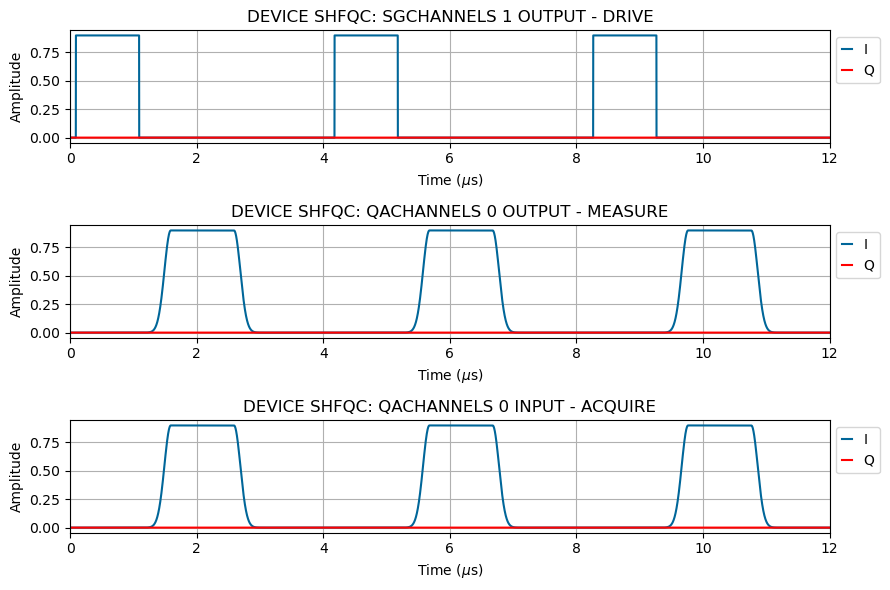

In [68]:
plot_simulation(compiled_qspec, start_time=0, length=12e-6)

In [69]:
# run the compiled experiemnt
qspec_results = session.run(compiled_qspec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(qspec_results, f"Results/{timestamp}_qspec_results.json")
print(f"File saved as Results/{timestamp}_qspec_results.json")

[2025.08.22 13:25:55.274] CRITICAL SHFQC/SG:dev12296: Local oscillator for channel 1 is required, but is not provided.


[2025.08.22 13:25:55.274] CRITICAL SHFQC/SG:dev12296: Local oscillator for channel 1 is required, but is not provided.


LabOneQControllerException: SHFQC/SG:dev12296: Local oscillator for channel 1 is required, but is not provided.

In [ ]:
plot_results(qspec_results, phase=True)

## Power Rabi & Time Rabi

In [ ]:
# range of pulse amplitude scan


def create_rabi_amp_sweep(amp_num, uid="rabi_amp"):
    amp_min = 0
    amp_max = 1
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4


# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=1e-6, amplitude=0.9):
    return pulse_library.gaussian(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

In [ ]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=num_averages,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation", alignment=SectionAlignment.RIGHT
            ):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.acquire(
                    signal="acquire",
                    handle="amp_rabi",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=1e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [ ]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_num=61))

# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [ ]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

In [ ]:
plot_simulation(compiled_rabi, start_time=0, length=100e-6)

In [ ]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(rabi_results,f"Results/{timestamp}_rabi_results.json")
print(f"File saved as Results/{timestamp}_rabi_results.json")

In [ ]:
plot_results(rabi_results)

In [ ]:
# get measurement data returned by the instruments
rabi_res = rabi_results.get_data("amp_rabi")

# define amplitude axis from qubit parameters
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

if use_emulation:
    # create some dummy data if running in emulation mode
    rabi_res = oscillatory(rabi_amp, 10, 0, 1, 1.2) + 0.2 * np.random.rand(
        len(rabi_amp)
    )

# plot measurement data
fig = plt.figure()
plt.plot(rabi_amp, rabi_res, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("amplitude (a.u.)")

# increase number of plot points for smooth plotting of fit results
amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))

# fit measurement results - assume sinusoidal oscillation with drive amplitude
popt, pcov = oscillatory.fit(rabi_amp, rabi_res, 10, 0, 1, 1.2, plot=False)
print(f"Fitted parameters: {popt}")

# plot fit results together with measurement data
plt.plot(amp_plot, oscillatory(amp_plot, *popt), "-r")
plt.show()